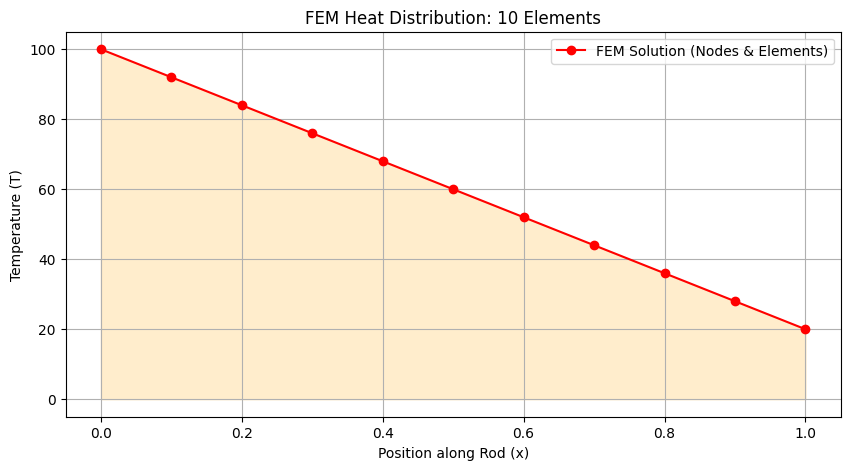

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Parameters
L = 1.0      # Length of rod
k = 1.0      # Thermal conductivity
T0 = 100     # Temp at left end (Celsius)
TL = 20      # Temp at right end (Celsius)
num_elements = 10
num_nodes = num_elements + 1
h = L / num_elements  # Element length

# 2. Initialize Global Stiffness Matrix (K) and Load Vector (F)
K = np.zeros((num_nodes, num_nodes))
F = np.zeros(num_nodes)

# 3. Assembly Process
# For each element, we calculate the local stiffness and add it to the global matrix
for i in range(num_elements):
    # Local stiffness matrix for a 1D linear element: (k/h) * [[1, -1], [-1, 1]]
    ke = (k / h) * np.array([[1, -1], [-1, 1]])
    
    # Map local nodes to global nodes
    K[i:i+2, i:i+2] += ke

# 4. Apply Boundary Conditions (Penalty Method or Direct Insertion)
# We know T[0] = T0 and T[-1] = TL. We modify the system to fix these values.
# Direct insertion:
K_reduced = K[1:-1, 1:-1]
F_reduced = np.zeros(num_nodes - 2)

# Adjust F based on the known boundary values
F_reduced[0] -= K[1, 0] * T0
F_reduced[-1] -= K[num_nodes-2, num_nodes-1] * TL

# 5. Solve for Interior Nodes
T_interior = np.linalg.solve(K_reduced, F_reduced)

# Combine boundary values with solved interior values
T = np.concatenate(([T0], T_interior, [TL]))
x = np.linspace(0, L, num_nodes)

# 6. Visualization
plt.figure(figsize=(10, 5))
plt.plot(x, T, 'ro-', label='FEM Solution (Nodes & Elements)')
plt.fill_between(x, T, alpha=0.2, color='orange') # Heat visual
plt.title(f'FEM Heat Distribution: {num_elements} Elements')
plt.xlabel('Position along Rod (x)')
plt.ylabel('Temperature (T)')
plt.grid(True)
plt.legend()
plt.show()

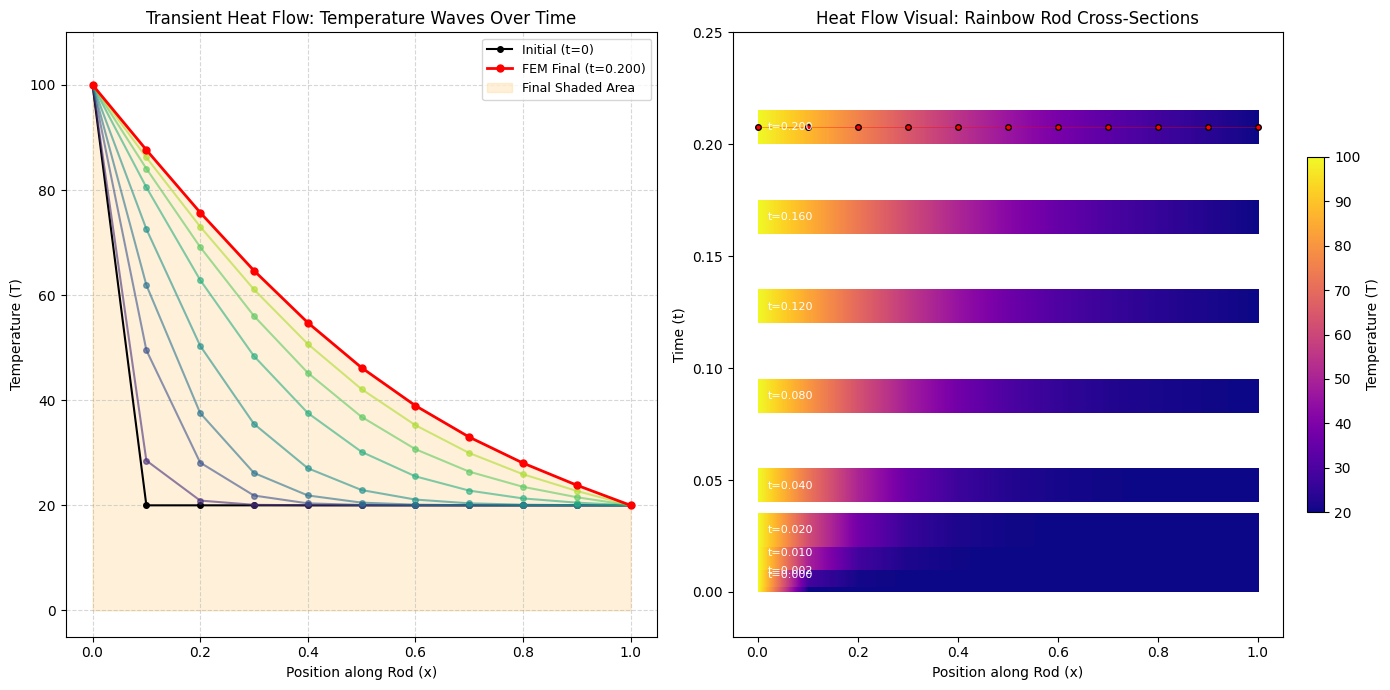

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Physical and Mesh Parameters
L = 1.0          # Length of rod
k = 1.0          # Thermal conductivity
rho = 1.0        # Density
cp = 1.5         # Specific heat
alpha = k / (rho * cp)  # Thermal diffusivity

# Boundary Conditions (fixed)
T0_left = 100.0  # Temperature at x=0
T0_right = 20.0  # Temperature at x=L

# FEM Discretization
num_elements = 10
num_nodes = num_elements + 1
x = np.linspace(0, L, num_nodes)
h = x[1] - x[0]  # Element length

# Time Discretization (Explicit method for simplicity)
dt = 0.002       # Time step (must be small for stability: dt <= h^2 / 2*alpha)
time_steps = 100 # Total number of steps to simulate

# 2. Stiffness and Mass Matrices (Simplified for 1D, linear elements)
# For linear elements, local stiffness is (k/h)[[1, -1],[-1, 1]]
# Global K is tridiagonal: [..., -k/h, 2k/h, -k/h, ...]
# For backward Euler, we modify it to (M/dt + K) where M is mass.
# We will use simple, lumped mass approximation M = rho*cp*h*I, so (M/dt + K) becomes simple.
# This makes solving much faster. We use (1/alpha/dt)*I + K'.

diag = np.full(num_nodes - 2, 2.0 / h**2)
off_diag = np.full(num_nodes - 3, -1.0 / h**2)
K_interior = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

# Modify matrix for time step and mass (implied mass lumped M=I)
M_K = (1.0 / alpha / dt) * np.eye(num_nodes - 2) + K_interior

# 3. Time Stepping
# Vector to store results at selected time steps for plotting
T_snapshots = []
times_snapshots = []

# Initial condition (Entire rod at right BC temperature)
T = np.full(num_nodes, T0_right)
# Set left BC for initial time
T[0] = T0_left

# Store initial state
T_snapshots.append(T.copy())
times_snapshots.append(0.0)

# Current time tracker
current_time = 0.0

# Backward Euler method loop
for step in range(1, time_steps + 1):
    current_time += dt

    # Force boundary conditions at the beginning of each step
    T[0] = T0_left
    T[-1] = T0_right

    # Construct Right Hand Side vector (T_prev / alpha / dt)
    RHS = (1.0 / alpha / dt) * T[1:-1]

    # Adjust RHS for boundary elements (K_01 * T0, K_10 * T0_right)
    # The tridiagonal k_interior has already incorporated the values inside.
    # We subtract the terms K_10 * T0_left and K_N,N-1 * T0_right from RHS.
    RHS[0] -= K_interior[0,0] * T0_left
    RHS[-1] -= K_interior[-1,-1] * T0_right

    # This seems complex. A simpler way for backward Euler:
    # RHS = T[1:-1] / dt
    # But it also needs k in.
    # Standard FEM mass/stiffness method is better:
    # (M + dt*K)T_new = M*T_prev + dt*F (F=0)
    # Lumped M = h*I. Standard M = (h/6)[[2,1],[1,2]]. Let's use standard M.

    # This explicit form is for the pure PDE form of the backward Euler (linear algebra, but derived from the PDE)
    # (1/alpha*h**2) * T_j+1,n - (1/dt + 2/alpha*h**2) T_j,n + (1/alpha*h**2) T_j-1,n = -1/dt * T_j,n-1
    # Actually, a simpler method is to discretize PDE in time first:
    # (T_n - T_n-1)/dt = alpha * d2T/dx2
    # Then spatial discretize d2T/dx2.
    # T_n - alpha*dt*d2T/dx2 = T_n-1
    # Let K' be spatial discrete laplacian. T_n + alpha*dt*K'*T_n = T_n-1
    # (I + alpha*dt*K')T_n = T_n-1

    # This is a very clean way to write it. We just need to define K'.
    diag_prime = np.full(num_nodes - 2, 2.0 / h**2)
    off_diag_prime = np.full(num_nodes - 3, -1.0 / h**2)
    K_prime_interior = np.diag(diag_prime) + np.diag(off_diag_prime, k=1) + np.diag(off_diag_prime, k=-1)
    # The matrix K' is a matrix such that K'*T approx -d2T/dx2.
    # But we want K'*T approx d2T/dx2, so we flip the signs.
    diag_prime = np.full(num_nodes - 2, -2.0 / h**2)
    off_diag_prime = np.full(num_nodes - 3, 1.0 / h**2)
    K_prime_interior = np.diag(diag_prime) + np.diag(off_diag_prime, k=1) + np.diag(off_diag_prime, k=-1)

    # Let's verify K':
    # d2T/dx2 approx (T_i+1 - 2T_i + T_i-1) / h**2. The K_prime_interior gives this.

    # Matrix for backward Euler: (I - alpha*dt*K_prime)
    A = np.eye(num_nodes - 2) - alpha * dt * K_prime_interior

    # Define RHS
    RHS = T[1:-1].copy()
    # Apply Dirichlet boundary terms to RHS (A * T_bc)
    # Term for left boundary condition T0 (x=0)
    RHS[0] -= (-1.0 * alpha * dt / h**2) * T0_left
    # Term for right boundary condition TL (x=L)
    RHS[-1] -= (-1.0 * alpha * dt / h**2) * T0_right

    # Solve the system
    T_new_interior = np.linalg.solve(A, RHS)

    # Reconstruct the T vector
    T_new = np.concatenate(([T0_left], T_new_interior, [T0_right]))
    T = T_new

    # Store results at selected time steps
    if step in [1, 5, 10, 20, 40, 60, 80, 100]:
        T_snapshots.append(T.copy())
        times_snapshots.append(current_time)

# 4. Define Interpolation functions for color visual (more interesting)
# Use interpolated values for smoother rod visual
x_smooth = np.linspace(0, L, 500)
# Use data plot to find y-limits and value range
T_min = T0_right
T_max = T0_left
# Normalize temperatures for colormap
norm = plt.Normalize(T_min, T_max)
cmap = plt.cm.plasma # or 'inferno', 'magma', 'hot', 'jet' - can choose

# 5. Visualization - Two Side-by-Side Plots
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# --- Left Plot: Time Series Line Graph (Wave visual) ---
ax1 = axs[0]
colors_wave = plt.cm.viridis(np.linspace(0, 1, len(T_snapshots)))

for i, (T_snapshot, t_val) in enumerate(zip(T_snapshots, times_snapshots)):
    if i == 0:
        # Initial state (black line with markers)
        ax1.plot(x, T_snapshot, 'o-', color='black', linewidth=1.5, markersize=4, label='Initial (t=0)')
    
    elif i == len(T_snapshots) - 1:
        # Final state (red line with markers)
        ax1.plot(x, T_snapshot, 'ro-', linewidth=2, markersize=5, label=f'FEM Final (t={t_val:.3f})')
    
    else:
        # Intermediate states (dynamic color matching for both line and markers)
        current_color = colors_wave[i]
        ax1.plot(x, T_snapshot, 'o-', color=current_color, alpha=0.6, markersize=4)

# Highlight the final FEM steady state curve with shading
f_smooth = interp1d(x, T_snapshots[-1], kind='linear')
T_smooth = f_smooth(x_smooth)
ax1.fill_between(x_smooth, 0, T_smooth, alpha=0.15, color='orange', label='Final Shaded Area')

ax1.set_title('Transient Heat Flow: Temperature Waves Over Time', fontsize=12)
ax1.set_xlabel('Position along Rod (x)')
ax1.set_ylabel('Temperature (T)')
ax1.set_ylim(-5, T0_left + 10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', prop={'size': 9})

# --- Right Plot: Physical Rod (Rainbow Tube Visual) ---
ax2 = axs[1]
for i, (T_snapshot, t_val) in enumerate(zip(T_snapshots, times_snapshots)):
    # Create smooth color data
    f_smooth_snapshot = interp1d(x, T_snapshot, kind='linear')
    T_smooth_snapshot = f_smooth_snapshot(x_smooth)

    # Define color data based on colormap
    colors_rod = cmap(norm(T_smooth_snapshot))

    # Add a thin colored bar visual on the right axis
    # Place them in a stack (0 to 1, then shift for next snapshot)
    ax2.imshow(colors_rod[np.newaxis, :], aspect='auto', extent=[0, L, t_val, t_val+0.015])

    # Annotation with time
    ax2.text(0.02, t_val + 0.0075, f't={t_val:.3f}', fontsize=8, color='white', ha='left', va='center')

# Highlight the nodes on the *physical rod* at final time step.
# Place markers at nodes on the final rod visual.
# The extend of the final rod is from t_final to t_final+offset. Node markers at that height.
t_final_val = times_snapshots[-1]
# Draw node positions over the final rod visual
nodes_height = t_final_val + 0.0075
ax2.plot(x, np.full(num_nodes, nodes_height), 'ro', markersize=4, markeredgecolor='black', label='Final Nodes')
ax2.plot(x, np.full(num_nodes, nodes_height), 'r-', linewidth=0.5, alpha=0.5) # thin line to link

ax2.set_title('Heat Flow Visual: Rainbow Rod Cross-Sections', fontsize=12)
ax2.set_xlabel('Position along Rod (x)')
ax2.set_ylabel('Time (t)')
ax2.set_ylim(-0.02, times_snapshots[-1] + 0.05)
ax2.set_xlim(-0.05, 1.05)
# No grid on the rod visual for cleaner view

# Add a colorbar to link the rod visual to temperature values
# Make a fake plot for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax2, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Temperature (T)')

plt.tight_layout()
plt.show()

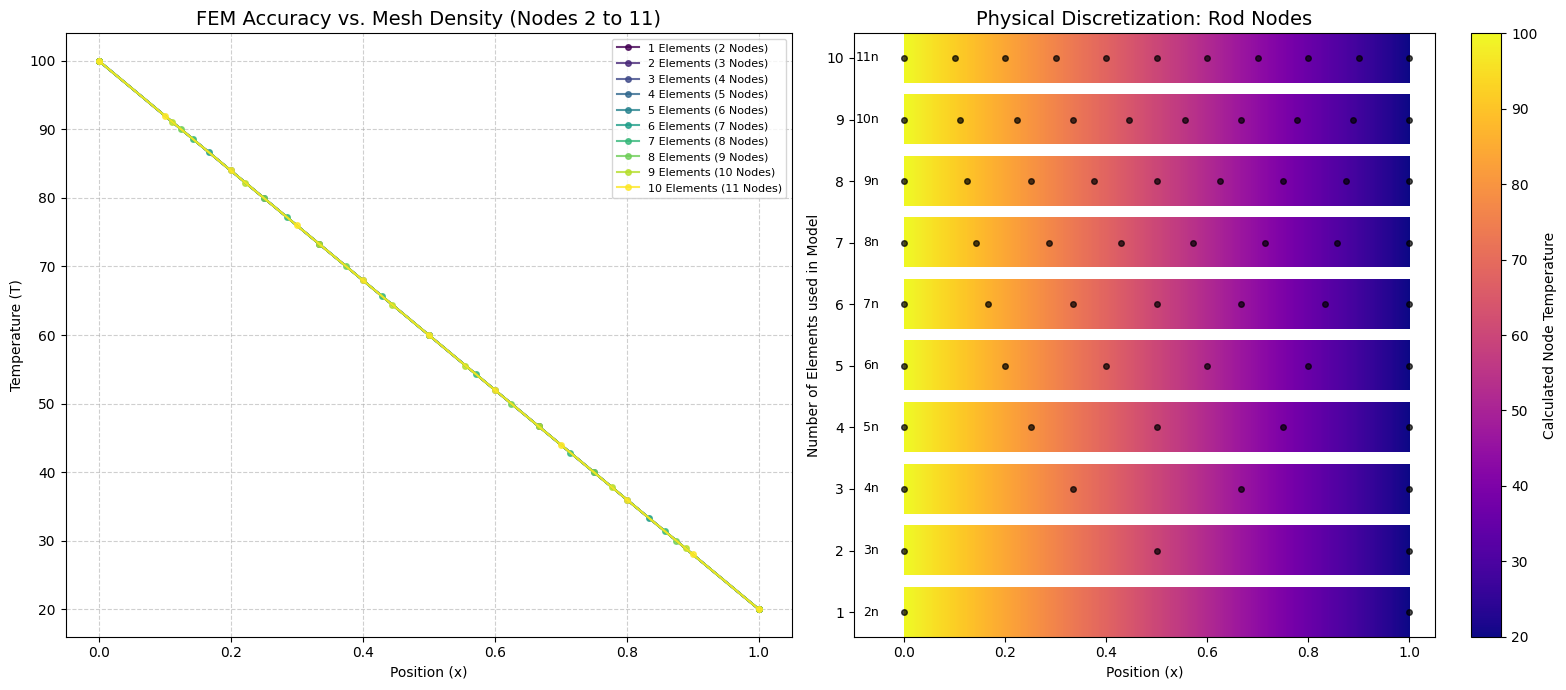

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Parameters
L = 1.0      # Length of rod
k = 1.0      # Thermal conductivity
T0 = 100     # Temp at left end
TL = 20      # Temp at right end

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.cm.plasma

# We will iterate from 1 element (2 nodes) up to 10 elements (11 nodes)
element_counts = range(1, 11)
colors = plt.cm.viridis(np.linspace(0, 1, len(element_counts)))

for i, num_elements in enumerate(element_counts):
    num_nodes = num_elements + 1
    x = np.linspace(0, L, num_nodes)
    h = L / num_elements
    
    # 2. Build Global Stiffness Matrix (K)
    K = np.zeros((num_nodes, num_nodes))
    for e in range(num_elements):
        ke = (k / h) * np.array([[1, -1], [-1, 1]])
        K[e:e+2, e:e+2] += ke

    # 3. Solve for Interior Nodes
    # Using the direct method: K_int * T_int = -K_bound * T_bound
    if num_elements > 1:
        K_reduced = K[1:-1, 1:-1]
        F_reduced = np.zeros(num_nodes - 2)
        F_reduced[0] -= K[1, 0] * T0
        F_reduced[-1] -= K[num_nodes-2, num_nodes-1] * TL
        T_interior = np.linalg.solve(K_reduced, F_reduced)
        T = np.concatenate(([T0], T_interior, [TL]))
    else:
        T = np.array([T0, TL]) # Case for 1 element (2 nodes)

    # --- Left Plot: Mesh Refinement ---
    label = f'{num_elements} Elements ({num_nodes} Nodes)'
    ax1.plot(x, T, 'o-', color=colors[i], label=label, alpha=0.8, markersize=4)

    # --- Right Plot: Rainbow Tube Visuals ---
    # We create a stack of "tubes" to show how the discretization looks physically
    # Higher y-position = more nodes
    y_pos = num_elements 
    
    # Create a smooth interpolation for the color bar visual
    x_fine = np.linspace(0, L, 200)
    T_fine = np.interp(x_fine, x, T)
    
    # Draw the "tube"
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap=cmap, 
               extent=[0, L, y_pos - 0.4, y_pos + 0.4], vmin=TL, vmax=T0)
    
    # Draw the actual NODES on top of the tube
    ax2.plot(x, np.full_like(x, y_pos), 'ko', markersize=4, alpha=0.7)
    ax2.text(-0.05, y_pos, f'{num_nodes}n', va='center', ha='right', fontsize=9)

# Formatting Left Plot
ax1.set_title('FEM Accuracy vs. Mesh Density (Nodes 2 to 11)', fontsize=14)
ax1.set_xlabel('Position (x)')
ax1.set_ylabel('Temperature (T)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Formatting Right Plot
ax2.set_title('Physical Discretization: Rod Nodes', fontsize=14)
ax2.set_xlabel('Position (x)')
ax2.set_ylabel('Number of Elements used in Model')
ax2.set_yticks(element_counts)
ax2.set_xlim(-0.1, 1.05)

# Add Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=TL, vmax=T0))
cbar = fig.colorbar(sm, ax=ax2)
cbar.set_label('Calculated Node Temperature')

plt.tight_layout()
plt.show()

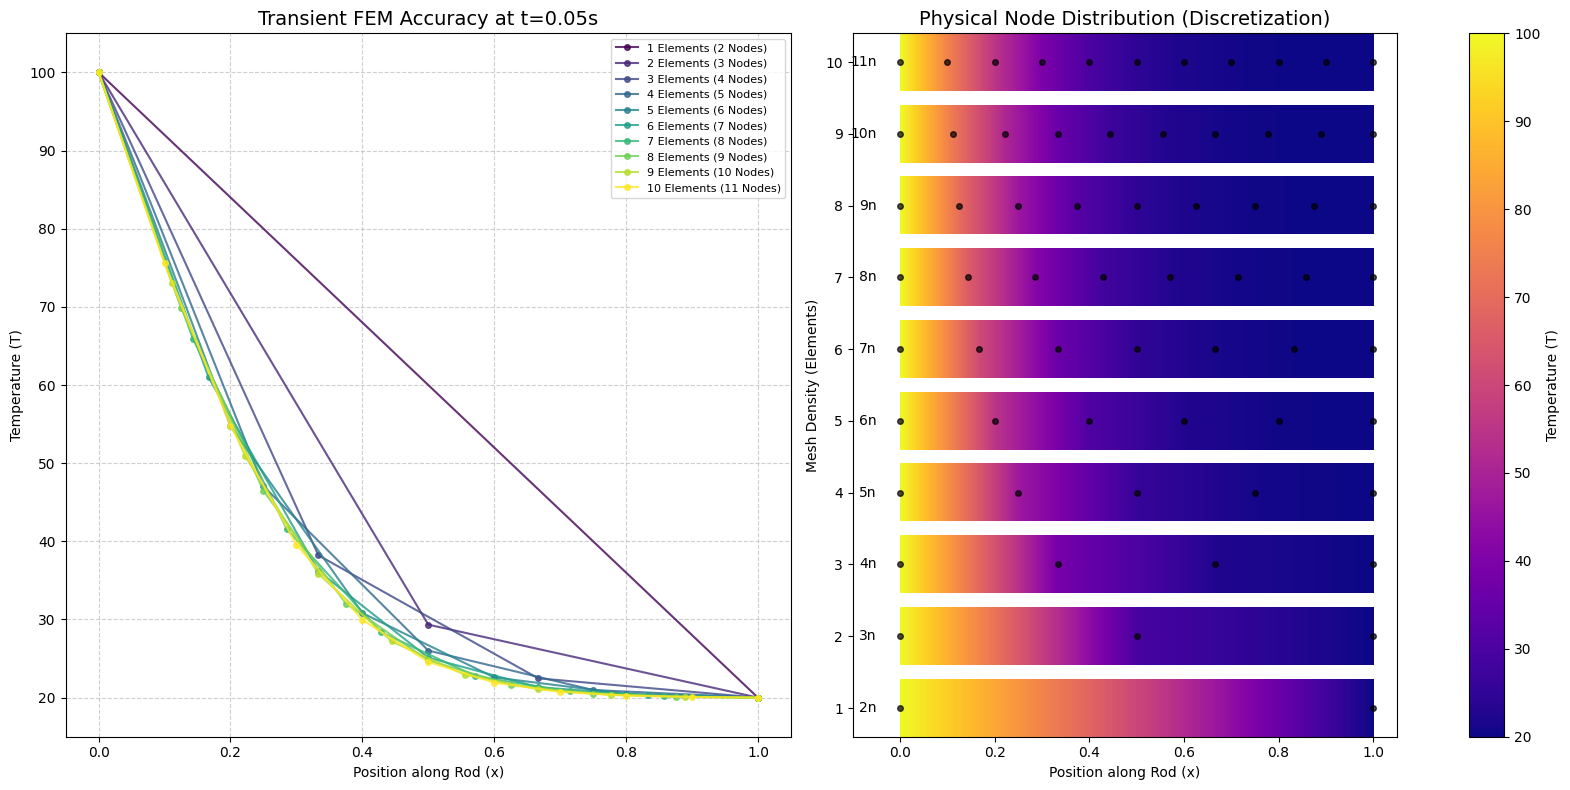

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Physical Parameters
L = 1.0          # Length of rod
k = 1.0          # Thermal conductivity
rho = 1.0        # Density
cp = 1.5         # Specific heat
alpha = k / (rho * cp)  # Thermal diffusivity

# Boundary Conditions
T0_left = 100.0
T0_right = 20.0

# Simulation Time Settings
dt = 0.001       # Small time step for stability
target_time = 0.05  # Compare all mesh densities at this specific time
steps = int(target_time / dt)

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
cmap = plt.cm.plasma

# Iterate from 1 element (2 nodes) to 10 elements (11 nodes)
element_counts = range(1, 11)
colors = plt.cm.viridis(np.linspace(0, 1, len(element_counts)))

for i, num_elements in enumerate(element_counts):
    num_nodes = num_elements + 1
    x = np.linspace(0, L, num_nodes)
    h = L / num_elements
    
    # Initial Condition: Entire rod at T0_right
    T = np.full(num_nodes, T0_right)
    T[0] = T0_left

    # 2. Transient Solver Logic
    # We only solve for interior nodes if there ARE interior nodes (num_elements > 1)
    if num_elements > 1:
        # Spatial Discretization (Second Derivative Matrix)
        diag = np.full(num_nodes - 2, -2.0 / h**2)
        off_diag = np.full(num_nodes - 3, 1.0 / h**2)
        K_prime = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
        
        # Backward Euler Matrix: (I - alpha * dt * K_prime)
        A = np.eye(num_nodes - 2) - alpha * dt * K_prime

        # Solve through time steps
        for _ in range(steps):
            RHS = T[1:-1].copy()
            # Boundary adjustments for the heat diffusion
            RHS[0] -= (-1.0 * alpha * dt / h**2) * T0_left
            RHS[-1] -= (-1.0 * alpha * dt / h**2) * T0_right
            
            T[1:-1] = np.linalg.solve(A, RHS)
    else:
        # 1 element case: Temperature is just a straight line between boundaries
        # at t=0.05, the heat hasn't "reached" the other side in a 1-element linear approximation
        pass

    # --- Left Plot: Compare Mesh Accuracy ---
    label = f'{num_elements} Elements ({num_nodes} Nodes)'
    ax1.plot(x, T, 'o-', color=colors[i], label=label, alpha=0.8, markersize=4)

    # --- Right Plot: Rainbow Tube Visuals ---
    y_pos = num_elements 
    x_fine = np.linspace(0, L, 300)
    # Use linear interpolation to show how the FEM "sees" the temperature between nodes
    T_fine = np.interp(x_fine, x, T) 
    
    # Draw the individual rod "tube"
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap=cmap, 
               extent=[0, L, y_pos - 0.4, y_pos + 0.4], vmin=T0_right, vmax=T0_left)
    
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap=cmap, 
               extent=[0, L, y_pos - 0.4, y_pos + 0.4], vmin=TL, vmax=T0)
    
    # Draw the actual NODES on top of the tube
    ax2.plot(x, np.full_like(x, y_pos), 'ko', markersize=4, alpha=0.7)
    ax2.text(-0.05, y_pos, f'{num_nodes}n', va='center', ha='right', fontsize=10)

# Final Formatting for the Poster Visuals
ax1.set_title(f'Transient FEM Accuracy at t={target_time}s', fontsize=14)
ax1.set_xlabel('Position along Rod (x)')
ax1.set_ylabel('Temperature (T)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(T0_right - 5, T0_left + 5)

ax2.set_title('Physical Node Distribution (Discretization)', fontsize=14)
ax2.set_xlabel('Position along Rod (x)')
ax2.set_ylabel('Mesh Density (Elements)')
ax2.set_yticks(element_counts)
ax2.set_xlim(-0.1, 1.05)

# Colorbar for temperature reference
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T0_right, vmax=T0_left))
cbar = fig.colorbar(sm, ax=ax2, pad=0.1)
cbar.set_label('Temperature (T)')

plt.tight_layout()
plt.show()

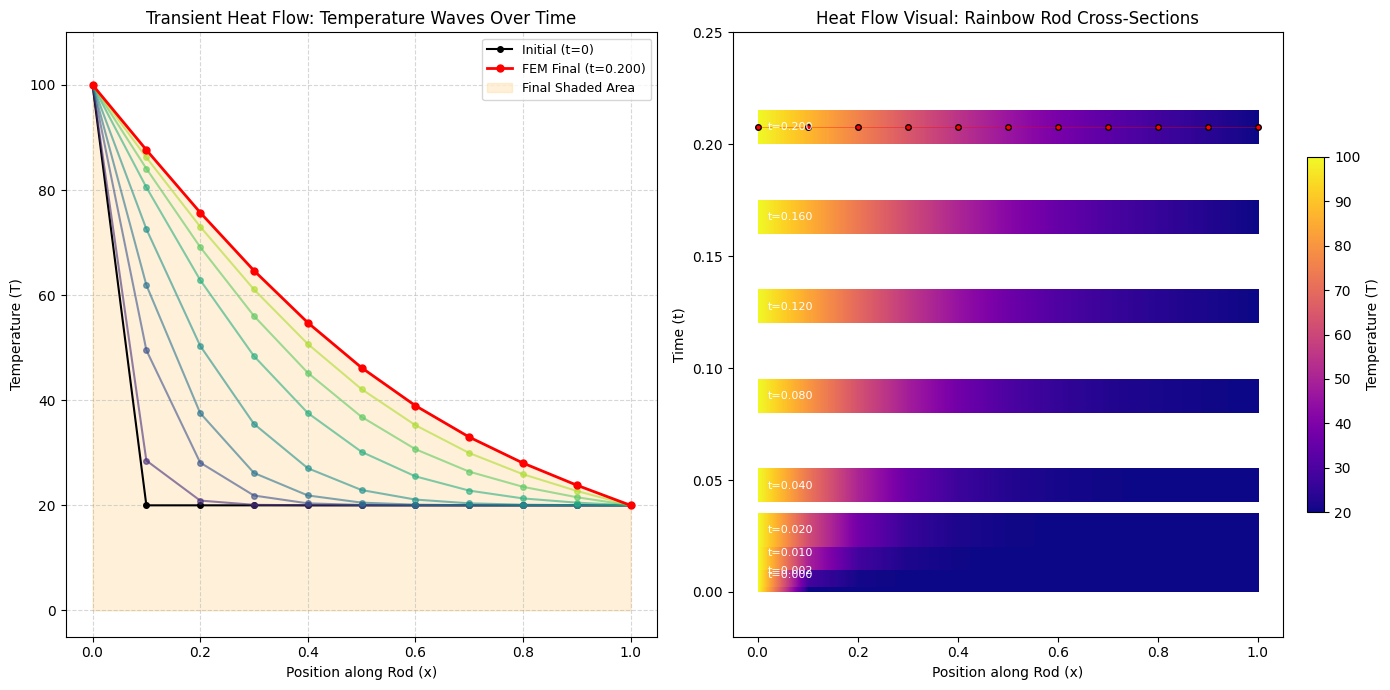

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Physical and Mesh Parameters
L = 1.0          # Length of rod
k = 1.0          # Thermal conductivity
rho = 1.0        # Density
cp = 1.5         # Specific heat
alpha = k / (rho * cp)  # Thermal diffusivity

# Boundary Conditions (fixed)
T0_left = 100.0  # Temperature at x=0
T0_right = 20.0  # Temperature at x=L

# FEM Discretization
num_elements = 10
num_nodes = num_elements + 1
x = np.linspace(0, L, num_nodes)
h = x[1] - x[0]  # Element length

# Time Discretization (Explicit method for simplicity)
dt = 0.002       # Time step (must be small for stability: dt <= h^2 / 2*alpha)
time_steps = 100 # Total number of steps to simulate

# 2. Stiffness and Mass Matrices (Simplified for 1D, linear elements)
# For linear elements, local stiffness is (k/h)[[1, -1],[-1, 1]]
# Global K is tridiagonal: [..., -k/h, 2k/h, -k/h, ...]
# For backward Euler, we modify it to (M/dt + K) where M is mass.
# We will use simple, lumped mass approximation M = rho*cp*h*I, so (M/dt + K) becomes simple.
# This makes solving much faster. We use (1/alpha/dt)*I + K'.

diag = np.full(num_nodes - 2, 2.0 / h**2)
off_diag = np.full(num_nodes - 3, -1.0 / h**2)
K_interior = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

# Modify matrix for time step and mass (implied mass lumped M=I)
M_K = (1.0 / alpha / dt) * np.eye(num_nodes - 2) + K_interior

# 3. Time Stepping
# Vector to store results at selected time steps for plotting
T_snapshots = []
times_snapshots = []

# Initial condition (Entire rod at right BC temperature)
T = np.full(num_nodes, T0_right)
# Set left BC for initial time
T[0] = T0_left

# Store initial state
T_snapshots.append(T.copy())
times_snapshots.append(0.0)

# Current time tracker
current_time = 0.0

# Backward Euler method loop
for step in range(1, time_steps + 1):
    current_time += dt

    # Force boundary conditions at the beginning of each step
    T[0] = T0_left
    T[-1] = T0_right

    # Construct Right Hand Side vector (T_prev / alpha / dt)
    RHS = (1.0 / alpha / dt) * T[1:-1]

    # Adjust RHS for boundary elements (K_01 * T0, K_10 * T0_right)
    # The tridiagonal k_interior has already incorporated the values inside.
    # We subtract the terms K_10 * T0_left and K_N,N-1 * T0_right from RHS.
    RHS[0] -= K_interior[0,0] * T0_left
    RHS[-1] -= K_interior[-1,-1] * T0_right

    # This seems complex. A simpler way for backward Euler:
    # RHS = T[1:-1] / dt
    # But it also needs k in.
    # Standard FEM mass/stiffness method is better:
    # (M + dt*K)T_new = M*T_prev + dt*F (F=0)
    # Lumped M = h*I. Standard M = (h/6)[[2,1],[1,2]]. Let's use standard M.

    # This explicit form is for the pure PDE form of the backward Euler (linear algebra, but derived from the PDE)
    # (1/alpha*h**2) * T_j+1,n - (1/dt + 2/alpha*h**2) T_j,n + (1/alpha*h**2) T_j-1,n = -1/dt * T_j,n-1
    # Actually, a simpler method is to discretize PDE in time first:
    # (T_n - T_n-1)/dt = alpha * d2T/dx2
    # Then spatial discretize d2T/dx2.
    # T_n - alpha*dt*d2T/dx2 = T_n-1
    # Let K' be spatial discrete laplacian. T_n + alpha*dt*K'*T_n = T_n-1
    # (I + alpha*dt*K')T_n = T_n-1

    # This is a very clean way to write it. We just need to define K'.
    diag_prime = np.full(num_nodes - 2, 2.0 / h**2)
    off_diag_prime = np.full(num_nodes - 3, -1.0 / h**2)
    K_prime_interior = np.diag(diag_prime) + np.diag(off_diag_prime, k=1) + np.diag(off_diag_prime, k=-1)
    # The matrix K' is a matrix such that K'*T approx -d2T/dx2.
    # But we want K'*T approx d2T/dx2, so we flip the signs.
    diag_prime = np.full(num_nodes - 2, -2.0 / h**2)
    off_diag_prime = np.full(num_nodes - 3, 1.0 / h**2)
    K_prime_interior = np.diag(diag_prime) + np.diag(off_diag_prime, k=1) + np.diag(off_diag_prime, k=-1)

    # Let's verify K':
    # d2T/dx2 approx (T_i+1 - 2T_i + T_i-1) / h**2. The K_prime_interior gives this.

    # Matrix for backward Euler: (I - alpha*dt*K_prime)
    A = np.eye(num_nodes - 2) - alpha * dt * K_prime_interior

    # Define RHS
    RHS = T[1:-1].copy()
    # Apply Dirichlet boundary terms to RHS (A * T_bc)
    # Term for left boundary condition T0 (x=0)
    RHS[0] -= (-1.0 * alpha * dt / h**2) * T0_left
    # Term for right boundary condition TL (x=L)
    RHS[-1] -= (-1.0 * alpha * dt / h**2) * T0_right

    # Solve the system
    T_new_interior = np.linalg.solve(A, RHS)

    # Reconstruct the T vector
    T_new = np.concatenate(([T0_left], T_new_interior, [T0_right]))
    T = T_new

    # Store results at selected time steps
    if step in [1, 5, 10, 20, 40, 60, 80, 100]:
        T_snapshots.append(T.copy())
        times_snapshots.append(current_time)

# 4. Define Interpolation functions for color visual (more interesting)
# Use interpolated values for smoother rod visual
x_smooth = np.linspace(0, L, 500)
# Use data plot to find y-limits and value range
T_min = T0_right
T_max = T0_left
# Normalize temperatures for colormap
norm = plt.Normalize(T_min, T_max)
cmap = plt.cm.plasma # or 'inferno', 'magma', 'hot', 'jet' - can choose

# 5. Visualization - Two Side-by-Side Plots
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# --- Left Plot: Time Series Line Graph (Wave visual) ---
ax1 = axs[0]
colors_wave = plt.cm.viridis(np.linspace(0, 1, len(T_snapshots)))

for i, (T_snapshot, t_val) in enumerate(zip(T_snapshots, times_snapshots)):
    if i == 0:
        # Initial state (black line with markers)
        ax1.plot(x, T_snapshot, 'o-', color='black', linewidth=1.5, markersize=4, label='Initial (t=0)')
    
    elif i == len(T_snapshots) - 1:
        # Final state (red line with markers)
        ax1.plot(x, T_snapshot, 'ro-', linewidth=2, markersize=5, label=f'FEM Final (t={t_val:.3f})')
    
    else:
        # Intermediate states (dynamic color matching for both line and markers)
        current_color = colors_wave[i]
        ax1.plot(x, T_snapshot, 'o-', color=current_color, alpha=0.6, markersize=4)

# Highlight the final FEM steady state curve with shading
f_smooth = interp1d(x, T_snapshots[-1], kind='linear')
T_smooth = f_smooth(x_smooth)
ax1.fill_between(x_smooth, 0, T_smooth, alpha=0.15, color='orange', label='Final Shaded Area')

ax1.set_title('Transient Heat Flow: Temperature Waves Over Time', fontsize=12)
ax1.set_xlabel('Position along Rod (x)')
ax1.set_ylabel('Temperature (T)')
ax1.set_ylim(-5, T0_left + 10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', prop={'size': 9})

# --- Right Plot: Physical Rod (Rainbow Tube Visual) ---
ax2 = axs[1]
for i, (T_snapshot, t_val) in enumerate(zip(T_snapshots, times_snapshots)):
    # Create smooth color data
    f_smooth_snapshot = interp1d(x, T_snapshot, kind='linear')
    T_smooth_snapshot = f_smooth_snapshot(x_smooth)

    # Define color data based on colormap
    colors_rod = cmap(norm(T_smooth_snapshot))

    # Add a thin colored bar visual on the right axis
    # Place them in a stack (0 to 1, then shift for next snapshot)
    ax2.imshow(colors_rod[np.newaxis, :], aspect='auto', extent=[0, L, t_val, t_val+0.015])

    # Annotation with time
    ax2.text(0.02, t_val + 0.0075, f't={t_val:.3f}', fontsize=8, color='white', ha='left', va='center')

# Highlight the nodes on the *physical rod* at final time step.
# Place markers at nodes on the final rod visual.
# The extend of the final rod is from t_final to t_final+offset. Node markers at that height.
t_final_val = times_snapshots[-1]
# Draw node positions over the final rod visual
nodes_height = t_final_val + 0.0075
ax2.plot(x, np.full(num_nodes, nodes_height), 'ro', markersize=4, markeredgecolor='black', label='Final Nodes')
ax2.plot(x, np.full(num_nodes, nodes_height), 'r-', linewidth=0.5, alpha=0.5) # thin line to link

ax2.set_title('Heat Flow Visual: Rainbow Rod Cross-Sections', fontsize=12)
ax2.set_xlabel('Position along Rod (x)')
ax2.set_ylabel('Time (t)')
ax2.set_ylim(-0.02, times_snapshots[-1] + 0.05)
ax2.set_xlim(-0.05, 1.05)
# No grid on the rod visual for cleaner view

# Add a colorbar to link the rod visual to temperature values
# Make a fake plot for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax2, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Temperature (T)')

plt.tight_layout()
plt.show()

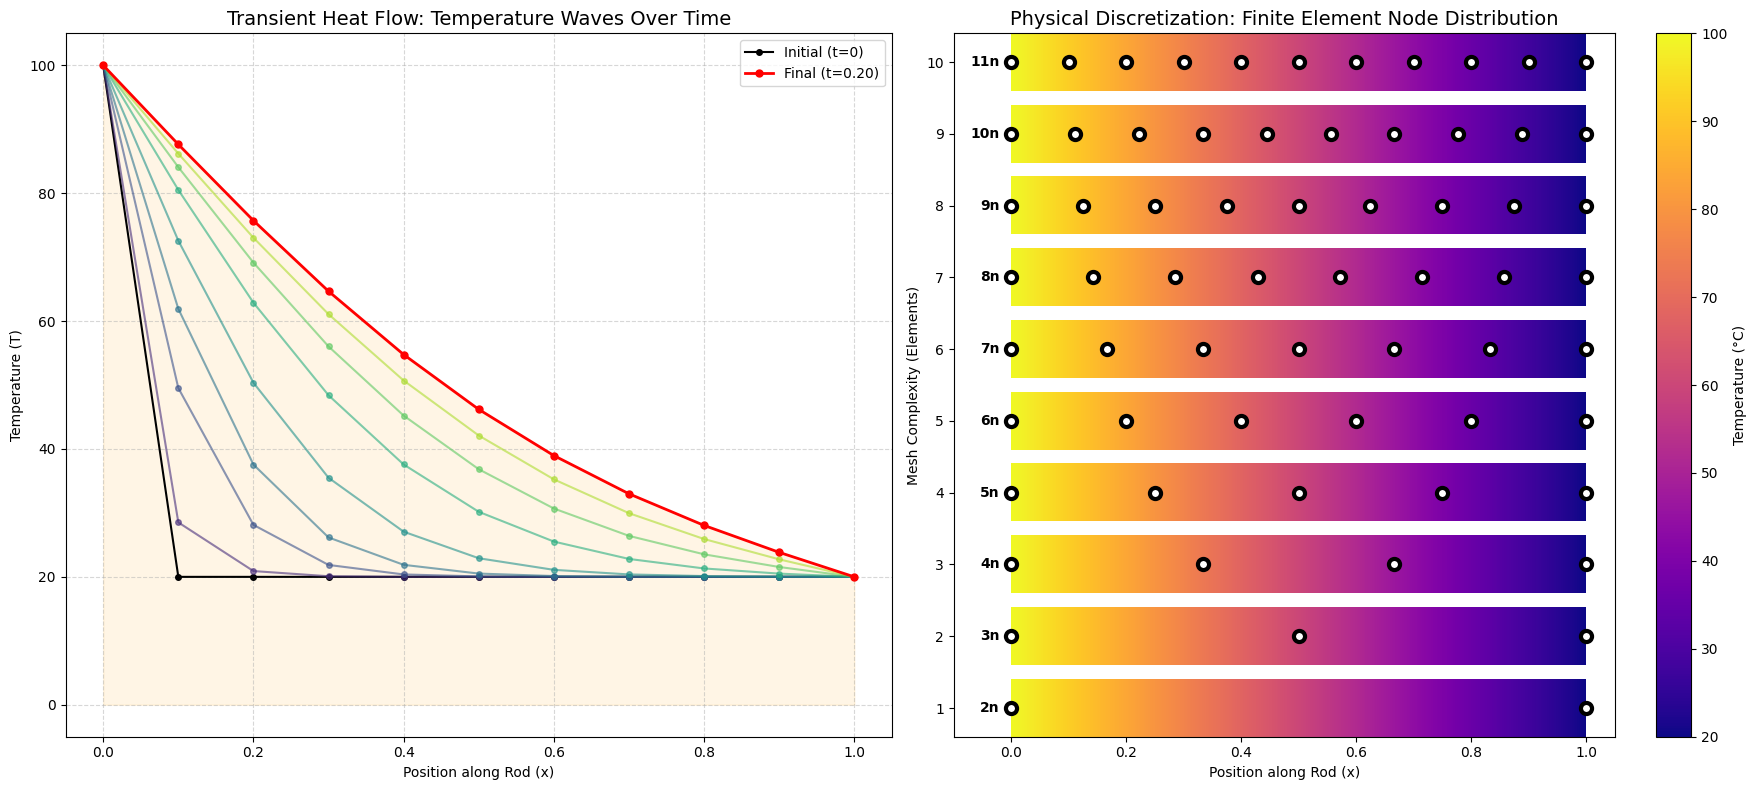

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Physical and Mesh Parameters
L = 1.0          # Length of rod
k = 1.0          # Thermal conductivity
rho = 1.0        # Density
cp = 1.5         # Specific heat
alpha = k / (rho * cp)  # Thermal diffusivity

# Boundary Conditions
T0_left = 100.0  # Hot end
T0_right = 20.0  # Cold end

# Simulation Settings for the Left Plot (Time Waves)
dt = 0.002       
time_steps = 100 
num_elements_wave = 10  # Keeping the wave plot at a stable 11 nodes
num_nodes_wave = num_elements_wave + 1
x_wave = np.linspace(0, L, num_nodes_wave)
h_wave = x_wave[1] - x_wave[0]

# --- PART 1: TRANSIENT SOLVER (For Left Plot) ---
T = np.full(num_nodes_wave, T0_right)
T[0] = T0_left
T_snapshots = [T.copy()]
times_snapshots = [0.0]

# Backward Euler Setup
diag = np.full(num_nodes_wave - 2, -2.0 / h_wave**2)
off_diag = np.full(num_nodes_wave - 3, 1.0 / h_wave**2)
K_prime = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
A = np.eye(num_nodes_wave - 2) - alpha * dt * K_prime

for step in range(1, time_steps + 1):
    RHS = T[1:-1].copy()
    RHS[0] -= (-1.0 * alpha * dt / h_wave**2) * T0_left
    RHS[-1] -= (-1.0 * alpha * dt / h_wave**2) * T0_right
    T[1:-1] = np.linalg.solve(A, RHS)
    
    if step in [1, 5, 10, 20, 40, 60, 80, 100]:
        T_snapshots.append(T.copy())
        times_snapshots.append(step * dt)

# --- PART 2: VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
cmap = plt.cm.plasma

# LEFT PLOT: Time Evolution Waves
colors_wave = plt.cm.viridis(np.linspace(0, 1, len(T_snapshots)))
x_smooth = np.linspace(0, L, 500)

for i, (T_snap, t_val) in enumerate(zip(T_snapshots, times_snapshots)):
    if i == 0:
        ax1.plot(x_wave, T_snap, 'o-', color='black', linewidth=1.5, markersize=4, label='Initial (t=0)')
    elif i == len(T_snapshots) - 1:
        ax1.plot(x_wave, T_snap, 'ro-', linewidth=2, markersize=5, label=f'Final (t={t_val:.2f})')
    else:
        ax1.plot(x_wave, T_snap, 'o-', color=colors_wave[i], alpha=0.6, markersize=4)

# Shading for the final wave
f_final = interp1d(x_wave, T_snapshots[-1], kind='linear')
ax1.fill_between(x_smooth, 0, f_final(x_smooth), alpha=0.1, color='orange')

ax1.set_title('Transient Heat Flow: Temperature Waves Over Time', fontsize=14)
ax1.set_xlabel('Position along Rod (x)')
ax1.set_ylabel('Temperature (T)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# RIGHT PLOT: Mesh Complexity (Node Rows)
element_counts = range(1, num_nodes_wave)
for num_elements in element_counts:
    num_nodes = num_elements + 1
    x_nodes = np.linspace(0, L, num_nodes)
    T_nodes = np.linspace(T0_left, T0_right, num_nodes) # Steady state linear gradient
    
    y_pos = num_elements 
    T_fine = np.interp(x_smooth, x_nodes, T_nodes)
    
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap=cmap, 
               extent=[0, L, y_pos - 0.4, y_pos + 0.4], vmin=T0_right, vmax=T0_left)
    ax2.plot(x_nodes, np.full_like(x_nodes, y_pos), 
         marker='o',             # Use circle markers
         markerfacecolor='white', # The 'empty' effect
         markeredgecolor='black', # Keep the border visible
         markeredgewidth=3,    # A slightly thicker rim for contrast
         markersize=8,           # Maintain the original size
         linestyle='None')
    ax2.text(-0.02, y_pos, f'{num_nodes}n', va='center', ha='right', fontweight='bold')

ax2.set_title('Physical Discretization: Finite Element Node Distribution', fontsize=14)
ax2.set_xlabel('Position along Rod (x)')
ax2.set_ylabel('Mesh Complexity (Elements)')
ax2.set_yticks(element_counts)
ax2.set_xlim(-0.1, 1.05)

# Shared Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T0_right, vmax=T0_left))
cbar = fig.colorbar(sm, ax=ax2, pad=0.05)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.show()

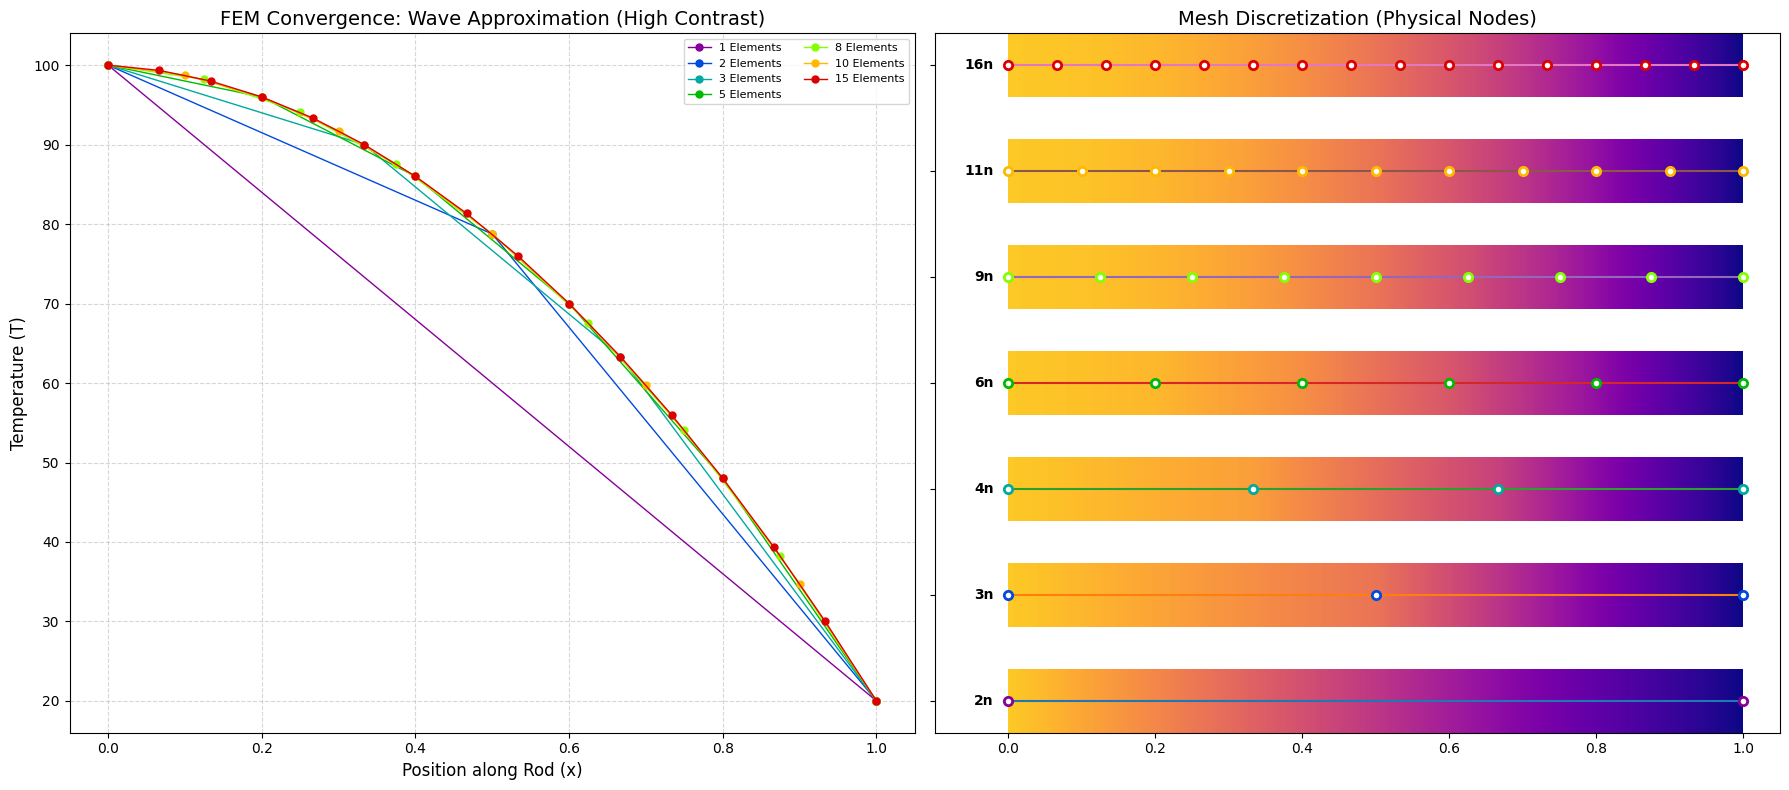

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Parameters
L, k, T0, TL, Q_source = 1.0, 1.0, 100, 20, 150.0 

# Explicit counts to highlight convergence gaps
element_counts = [1, 2, 3, 5, 8, 10, 15] 

# 2. Use 'nipy_spectral' for the highest-contrast rainbow effect.
# We slice it to skip the initial black so we start with deep purples.
colors = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, len(element_counts)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for i, num_elements in enumerate(element_counts):
    num_nodes = num_elements + 1
    x = np.linspace(0, L, num_nodes)
    h = L / num_elements
    
    # FEM SOLVER
    K = np.zeros((num_nodes, num_nodes))
    F = np.zeros(num_nodes)
    for e in range(num_elements):
        K[e:e+2, e:e+2] += (k / h) * np.array([[1, -1], [-1, 1]])
        F[e:e+2] += (Q_source * h / 2.0) * np.array([1, 1])

    if num_elements > 1:
        K_int = K[1:-1, 1:-1]
        F_int = F[1:-1] - (K[1:-1, 0] * T0) - (K[1:-1, -1] * TL)
        T_sol = np.concatenate(([T0], np.linalg.solve(K_int, F_int), [TL]))
    else:
        T_sol = np.array([T0, TL])

    # --- LEFT PLOT (CONVERGENCE) ---
    # Coarse models (low nodes) get thin lines; refined models (high nodes) get thick lines.
    lw = 1 + (i * 0.4) 
    ax1.plot(x, T_sol, 'o-', color=colors[i], 
             label=f'{num_elements} Elements', linewidth=1, markersize=5)

    # --- RIGHT PLOT (ROD VISUAL) ---
    y_pos = i  # Stacking for clarity
    x_fine = np.linspace(0, L, 300)
    T_fine = np.interp(x_fine, x, T_sol)
    
    # Rod uses plasma for heat visual, but nodes use our new rainbow colors.
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap='plasma', 
               extent=[0, L, y_pos - 0.3, y_pos + 0.3], vmin=20, vmax=110)
    
    # Empty nodes with colored rims for maximum contrast.
    ax2.plot(x, np.full_like(x, y_pos), marker='o', 
             markerfacecolor='white', markeredgecolor=colors[i], 
             markeredgewidth=2, markersize=6)
    
    ax2.text(-0.02, y_pos, f'{num_nodes}n', va='center', ha='right', fontweight='bold', fontsize=10)

# Formatting
ax1.set_title('FEM Convergence: Wave Approximation (High Contrast)', fontsize=14)
ax1.set_xlabel('Position along Rod (x)', fontsize=12)
ax1.set_ylabel('Temperature (T)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(ncol=2, fontsize=8) # 2-column legend to stay compact

ax2.set_title('Mesh Discretization (Physical Nodes)', fontsize=14)
ax2.set_yticks(range(len(element_counts)))
ax2.set_yticklabels([]) # Hide default y-ticks
ax2.set_xlim(-0.1, 1.05)

plt.tight_layout()
plt.savefig("Project_Image_1", bbox_inches='tight')
plt.show()

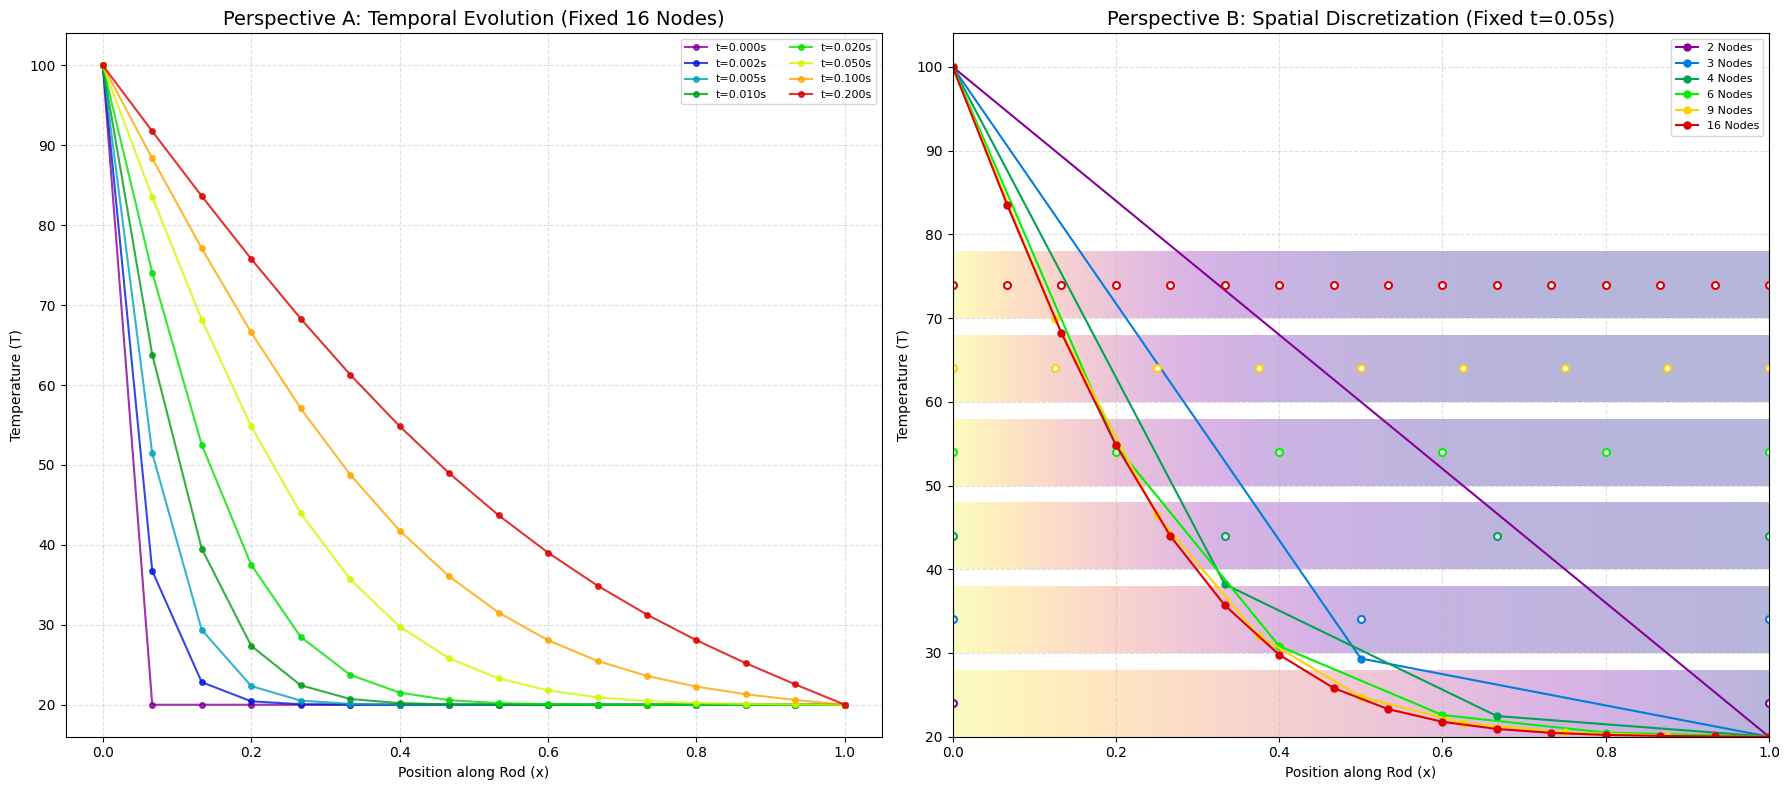

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Parameters (Unified for both perspectives)
L, k, rho, cp = 1.0, 1.0, 1.0, 1.5
alpha = k / (rho * cp)
T0_left, T0_right = 100.0, 20.0
dt = 0.001
target_time = 0.05  # The "Snapshot" time for the right graph

def solve_transient(num_elements, total_time, dt_val):
    num_nodes = num_elements + 1
    x = np.linspace(0, L, num_nodes)
    h = L / num_elements
    T = np.full(num_nodes, T0_right)
    T[0] = T0_left
    
    steps = int(total_time / dt_val)
    
    # We only build the matrix if there are interior nodes (num_elements > 1)
    if num_elements > 1:
        diag = np.full(num_nodes - 2, -2.0 / h**2)
        off_diag = np.full(num_nodes - 3, 1.0 / h**2)
        K_prime = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
        A = np.eye(num_nodes - 2) - alpha * dt_val * K_prime

        history = [(0.0, T.copy())]
        for s in range(1, steps + 1):
            RHS = T[1:-1].copy()
            # Boundary adjustments
            RHS[0] -= (-1.0 * alpha * dt_val / h**2) * T0_left
            RHS[-1] -= (-1.0 * alpha * dt_val / h**2) * T0_right
            T[1:-1] = np.linalg.solve(A, RHS)
            history.append((s * dt_val, T.copy()))
    else:
        # Case for 1 element: Linear interpolation between boundaries
        history = [(0.0, T.copy())]
        for s in range(1, steps + 1):
            # In a 1-element model, the "wave" is just a straight line
            history.append((s * dt_val, T.copy()))
            
    return x, history

# --- EXECUTION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# LEFT: Perspective A - Temporal Evolution (Fixed Mesh: 15 elements)
x_fixed, wave_history = solve_transient(15, 0.2, dt)
indices = [0, 2, 5, 10, 20, 50, 100, 200]
colors_time = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, len(indices)))

for i, idx in enumerate(indices):
    t_val, T_snap = wave_history[idx]
    ax1.plot(x_fixed, T_snap, 'o-', color=colors_time[i], 
             label=f"t={t_val:.3f}s", markersize=4, alpha=0.8)

ax1.set_title("Perspective A: Temporal Evolution (Fixed 16 Nodes)", fontsize=14)
ax1.set_xlabel("Position along Rod (x)")
ax1.set_ylabel("Temperature (T)")
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, ls='--', alpha=0.4)

# RIGHT: Perspective B - Spatial Discretization (Fixed Time: 0.05s)
element_counts = [1, 2, 3, 5, 8, 15]
colors_res = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, len(element_counts)))

for i, n_elem in enumerate(element_counts):
    x_var, hist_var = solve_transient(n_elem, target_time, dt)
    _, T_final = hist_var[-1]
    
    # Plot curves
    ax2.plot(x_var, T_final, 'o-', color=colors_res[i], 
             label=f"{n_elem+1} Nodes", markersize=5)
    
    # Rod Visuals (Rainbow Bars) in background
    y_pos = i
    x_fine = np.linspace(0, L, 300)
    T_fine = np.interp(x_fine, x_var, T_final)
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap='plasma', 
               extent=[0, L, y_pos*10 + 20, y_pos*10 + 28], vmin=20, vmax=100, alpha=0.3)
    
    # Add empty nodes (white center) for maximum contrast
    ax2.plot(x_var, np.full_like(x_var, y_pos*10 + 24), marker='o', 
             markerfacecolor='white', markeredgecolor=colors_res[i], 
             markeredgewidth=1.5, markersize=5, linestyle='None')

ax2.set_title(f"Perspective B: Spatial Discretization (Fixed t={target_time}s)", fontsize=14)
ax2.set_xlabel("Position along Rod (x)")
ax2.set_ylabel("Temperature (T)")
ax2.legend(fontsize=8)
ax2.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig("Project_Image_2", bbox_inches='tight')
plt.show()